# AI Stock Forecasting (AAPL) — Complete Colab Project
โปรเจกต์ตัวอย่าง **คาดการณ์ราคาปิดวันถัดไปของหุ้น Apple (AAPL)** ด้วย Machine Learning (Random Forest)  
รันได้บน **Google Colab** ทันที

**Pipeline**
1. ติดตั้งไลบรารี (ถ้ายังไม่มี)
2. ดาวน์โหลดข้อมูลหุ้นจาก Yahoo Finance (`yfinance`) — กันพลาด MultiIndex
3. สร้างฟีเจอร์ทางเทคนิค (Return, MA5, MA20, RSI14)
4. แบ่ง Train/Test + สเกลข้อมูล
5. เทรนโมเดล `RandomForestRegressor`
6. ประเมินผล (MAE, RMSE, MAPE) + กราฟ Actual vs Predicted
7. คาดการณ์ราคาปิดวันถัดไป
8. (ทางเลือก) ทำ Classification: ขึ้น/ลง
9. บันทึกโมเดลและไฟล์ผลลัพธ์

> หมายเหตุ: โค้ดนี้ตั้งใจเขียนให้ **ทนทานต่อรูปแบบคอลัมน์** ที่ yfinance ส่งกลับมา ทั้งคอลัมน์ชั้นเดียวและ MultiIndex


In [2]:
# 0) Install libraries (run if needed)
!pip install yfinance ta scikit-learn matplotlib --quiet

  Preparing metadata (setup.py) ... done


In [3]:
# 1) Imports & Config
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

from ta.momentum import RSIIndicator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score
import joblib

# ===== Settings =====
TICKER = "AAPL"       # เปลี่ยนได้ เช่น 'MSFT', '^SET'
START  = "2018-01-01"
TEST_SIZE = 0.2
N_ESTIMATORS = 400
RANDOM_STATE = 42
print(f"Ticker: {TICKER} | Start: {START}")

Ticker: AAPL | Start: 2018-01-01


In [4]:
# 2) Download data (time-fixed): end=พรุ่งนี้ (exclusive), prepost=True, merge .download() + .history()
def to_utc_naive(idx: pd.DatetimeIndex) -> pd.DatetimeIndex:
    di = pd.DatetimeIndex(idx)
    if di.tz is None:
        di = di.tz_localize("UTC")
    else:
        di = di.tz_convert("UTC")
    return di.tz_localize(None)

END = (pd.Timestamp.utcnow() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

df1 = yf.download(TICKER, start=START, end=END, interval="1d",
                  prepost=True, auto_adjust=False, repair=True,
                  progress=False, threads=False)

df2 = yf.Ticker(TICKER).history(start=START, end=END, interval="1d", auto_adjust=False)

# unify index timezone/awareness
if isinstance(df1.index, pd.DatetimeIndex): df1.index = to_utc_naive(df1.index)
if isinstance(df2.index, pd.DatetimeIndex): df2.index = to_utc_naive(df2.index)

# merge + drop duplicates
df = pd.concat([df1, df2], axis=0)
df = df[~df.index.duplicated(keep="last")].sort_index()

# keep core columns if present
cols = [c for c in ["Open","High","Low","Close","Adj Close","Volume"] if c in df.columns]
df = df[cols].copy()

# ensure numeric types
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Close"]).copy()

print("Last 5 dates:", df.index[-5:])
print("Latest date in df:", df.index[-1].date())
df.tail(3)

Last 5 dates: DatetimeIndex(['2025-10-13 04:00:00', '2025-10-14 04:00:00',
               '2025-10-15 04:00:00', '2025-10-16 04:00:00',
               '2025-10-17 04:00:00'],
              dtype='datetime64[ns]', name='Date', freq=None)
Latest date in df: 2025-10-17


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2025-10-15 04:00:00,249.490005,251.820007,247.470001,249.339996,249.339996,33893600.0
2025-10-16 04:00:00,248.250000,249.039993,245.130005,247.449997,247.449997,39777000.0
2025-10-17 04:00:00,248.020004,253.380005,247.270004,252.289993,252.289993,48876500.0


In [5]:
# 3) Feature Engineering
df["Return"] = np.log(df["Close"]).diff()
df["MA5"]  = df["Close"].rolling(window=5).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()
df["RSI14"] = RSIIndicator(close=df["Close"], window=14).rsi()

# แยกตารางเต็ม vs ตารางเทรน (ป้องกัน shift/dropna ทำให้เสียแถวล่าสุด)
df_full = df.copy()
df_ml = df_full.copy()
df_ml["y_reg"] = df_ml["Close"].shift(-1)
df_ml["y_cls"] = (df_ml["Close"].shift(-1) > df_ml["Close"]).astype(int)
df_ml = df_ml.dropna().copy()

features = [c for c in ["Close","Return","MA5","MA20","RSI14","Volume"] if c in df_ml.columns]
if "Volume" in df_ml.columns:
    df_ml["Volume"] = df_ml["Volume"].replace(0, np.nan).fillna(method="ffill")

X = df_ml[features].values
y = df_ml["y_reg"].values

len(df_ml), df_full.index[-1].date()

/tmp/ipython-input-3107543331.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ml["Volume"] = df_ml["Volume"].replace(0, np.nan).fillna(method="ffill")


(1940, datetime.date(2025, 10, 17))

In [6]:
# 4) Train/Test split + Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, shuffle=False)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc.shape, X_test_sc.shape, y_train.shape, y_test.shape

((1552, 6), (388, 6), (1552,), (388,))

In [7]:
# 5) Train Regression model + Evaluate
model = RandomForestRegressor(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_train_sc, y_train)

pred  = model.predict(X_test_sc)
mae   = mean_absolute_error(y_test, pred)
rmse  = mean_squared_error(y_test, pred) ** 0.5   # sqrt(MSE) รองรับทุกเวอร์ชัน
mape  = np.mean(np.abs((y_test - pred) / y_test)) * 100

print(f"MAE  : {mae:,.4f}")
print(f"RMSE : {rmse:,.4f}")
print(f"MAPE : {mape:,.2f}%")

MAE  : 25.8711
RMSE : 31.0234
MAPE : 11.18%


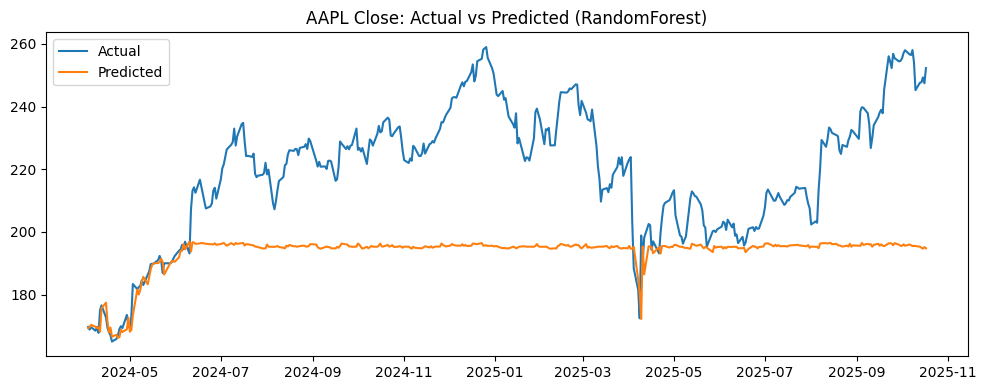

In [12]:
# 6) Plot Actual vs Predicted (single-plot, matplotlib only, no explicit colors)
plt.figure(figsize=(10,4))
idx = df.index[-len(y_test):]
plt.plot(idx, y_test, label="Actual")
plt.plot(idx, pred, label="Predicted")
plt.title(f"{TICKER} Close: Actual vs Predicted (RandomForest)")
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# 7) Predict next-day close (use features from df_full: ไม่ถูก shift/dropna ตัดทิ้ง)
print("ข้อมูลล่าสุดวันที่ :", df_full.index[-1].date())
print("ราคาปิดล่าสุด     :", round(df_full.iloc[-1]["Close"], 2))

last_feat    = df_full.iloc[[-1]][features].values
last_feat_sc = scaler.transform(last_feat)
next_price   = model.predict(last_feat_sc)[0]
print("คาดการณ์ราคาปิดวันถัดไป :", round(next_price, 2))

ข้อมูลล่าสุดวันที่ : 2025-10-17
ราคาปิดล่าสุด     : 252.29
คาดการณ์ราคาปิดวันถัดไป : 196.0


In [10]:
# 8) (Optional) Classification: predict direction (Up=1 / Not up=0)
# ใช้ชุด feature/scale เดียวกันเพื่อความสอดคล้อง
clf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1)
y_train_cls = df_ml["y_cls"].values[:len(y_train)]
y_test_cls  = df_ml["y_cls"].values[-len(y_test):]

clf.fit(X_train_sc, y_train_cls)
cls_pred = clf.predict(X_test_sc)

print("Classification Accuracy:", round(accuracy_score(y_test_cls, cls_pred), 4))
print("Classification F1-score:", round(f1_score(y_test_cls, cls_pred), 4))

Classification Accuracy: 0.451
Classification F1-score: 0.1088


In [11]:
# 9) Save artifacts (model, scaler, features, predictions) into /content
date_tag = date.today().strftime("%Y%m%d")
model_path   = f"rf_regressor_{TICKER}_{date_tag}.pkl"
scaler_path  = f"scaler_{TICKER}_{date_tag}.pkl"
preds_path   = f"predictions_{TICKER}_{date_tag}.csv"

joblib.dump(model, model_path)
joblib.dump((scaler, features), scaler_path)

out = pd.DataFrame({
    "date": [d.date() for d in df.index[-len(y_test):]],
    "actual_close": y_test,
    "pred_close": pred
})
out.to_csv(preds_path, index=False)

print("Saved: ", model_path, scaler_path, preds_path)

Saved:  rf_regressor_AAPL_20251019.pkl scaler_AAPL_20251019.pkl predictions_AAPL_20251019.csv
